In [7]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index
from simulate_population import sim_population


In [112]:
from Class_definitions import simplecox, CoxNN, cox_partial_loglik, prepare_data_for_cox, MultiCoxNN 
from Class_definitions import  MultiCoxNN, prepare_data_for_multicox, train_coxmulti
from Class_definitions import DiscreteTimeNN, prepare_data_for_event,MultiDiscreteTimeNN, prepare_data_for_multibinary, train_binmulti, get_cindex_multibinary
from Class_definitions import SimpleBinaryTimeSeries, train_simple_timeseries,prepare_data_simple_timeseries,get_cindex_simple_timeseries

In [111]:
import importlib, sys
# Force reload the module
importlib.reload(sys.modules['Class_definitions'])
# Now import again


<module 'Class_definitions' from '/Users/k1514174/Documents/GitHub/medicaljourneys/Class_definitions.py'>

In [113]:
# ============================================================================
# HYPERPARAMETERS (matching Simple_Cox_with_NN-Copy1)
# ============================================================================
BATCH_SIZE = 512
EPOCHS = 300
HIDDEN_LAYERS_COX = (16, 16)
HIDDEN_LAYERS_MULTIBINARY = (32, 32)
HIDDEN_LAYERS_SIMPLE_TIME_SERIES = (32, 32)
STEP_FORWARD = 2
N_STEPS = 5
N_INTERVALS = 50
COVARIATE_COLS = ["age_start", "bmi", "hyp", "smoke", "sex", "eth1", "eth2"]
EVENT_TYPES = ["a", "b", "c", "d", "e"]

PREVALENT_COLS   = [f"prev_{e}" for e in EVENT_TYPES]   # ["prev_a", ..., "prev_e"]
EXTENDED_COLS    = COVARIATE_COLS + PREVALENT_COLS       # baseline + prior events


In [126]:
# ============================================================================
# PART A: Generate Data
# ============================================================================
print("=" * 80)
print("PART A: Generating Simulation Data")
print("=" * 80)
# Set random seed for reproducibility
np.random.seed(420)
torch.manual_seed(420)

# Generate population with 5 steps forward, step_forward=2
population = sim_population(N=20000, step_forward=STEP_FORWARD, randomseed=420+15)
for i in range(N_STEPS):
    population.step()
    print(f"Step {i+1}/{N_STEPS} completed")

# Get Cox format data (train/test split)
df_cox = population.to_cox_format()
print(f"\nCox format data shape: {df_cox.shape}")
print(f"Columns: {df_cox.columns.tolist()[:15]}...")

# 80/20 train/test split
n_train = int(0.8 * len(df_cox))
df_short = df_cox.iloc[:n_train].reset_index(drop=True)
df_test = df_cox.iloc[n_train:].reset_index(drop=True)

print(f"\nTrain set: {len(df_short)} samples")
print(f"Test set: {len(df_test)} samples")

PART A: Generating Simulation Data
Step 1/5 completed
Step 2/5 completed
Step 3/5 completed
Step 4/5 completed
Step 5/5 completed

Cox format data shape: (20000, 18)
Columns: ['id', 'age_start', 'bmi', 'hyp', 'smoke', 'sex', 'eth1', 'eth2', 'event_a', 'time_a', 'event_b', 'time_b', 'event_c', 'time_c', 'event_d']...

Train set: 16000 samples
Test set: 4000 samples


In [127]:
# ============================================================================
# PART A2: Long format data for binary classification time-series model
# ============================================================================
# --- Prepare long-format data, filtered to train patient IDs ---
train_ids   = set(df_short["id"].values)
df_long_all = prepare_data_simple_timeseries(population)

df_long_train = df_long_all[df_long_all["id"].isin(train_ids)].reset_index(drop=True)
df_long_test = df_long_all[ df_long_all["id"].isin(train_ids)== False].reset_index(drop=True)
print(f"  Long-format train rows: {len(df_long_train)}  "
          f"({df_long_train['interval'].nunique()} intervals, "
          f"{df_long_train['id'].nunique()} patients)")

  Long-format train rows: 96000  (6 intervals, 16000 patients)


In [128]:
# ============================================================================
# PART B & C: Initialize & Train Models
# ============================================================================
print("\n" + "=" * 80)
print("PART B & C: Training Models")
print("=" * 80)

models = {}
cindex_results = {}

# -------- 1. Lifelines Cox (Baseline) --------
print("\n[1/7] Training Lifelines Cox Model...")
models['lifelines_cox'] = {}
for event in EVENT_TYPES:
    print(f"  → Event {event}...", end=" ")
    cph = CoxPHFitter()
    time_col = f"time_{event}"
    event_col = f"event_{event}"
    cph.fit(df_short[[time_col, event_col] + COVARIATE_COLS], 
            duration_col=time_col, event_col=event_col)
    models['lifelines_cox'][event] = cph
    print("done")

# -------- 2. Multi-Outcome Cox (NO Hidden Layers) --------
print("\n[2/7] Training Multi-Outcome Cox (No Hidden Layers)...")
x2_train, time2_train, event2_train = prepare_data_for_multicox(
    df_short, 
    covariate_cols=COVARIATE_COLS,
    time_cols=[f"time_{e}" for e in EVENT_TYPES],
    event_cols=[f"event_{e}" for e in EVENT_TYPES]
)
models['multicox_no_hidden'] = train_coxmulti(
    x2_train, time2_train, event2_train, 
    hidden_dims=(), epochs=EPOCHS, K=5
)
print("done")

# -------- 3. Multi-Outcome Cox (WITH Hidden Layers) --------
print("\n[3/7] Training Multi-Outcome Cox (With Hidden Layers)...")
models['multicox_with_hidden'] = train_coxmulti(
    x2_train, time2_train, event2_train, 
    hidden_dims=HIDDEN_LAYERS_COX, epochs=EPOCHS, K=5
)
print("done")

# -------- 4. Multi-Binary (NO Hidden Layers) --------
print("\n[4/7] Training Multi-Binary Model (No Hidden Layers)...")
X_train, intervals_train, events_train, n_intervals = prepare_data_for_multibinary(
    df_short, 
    features=COVARIATE_COLS,
    event_types=EVENT_TYPES,
    n_intervals=N_INTERVALS,
    even_split=True  # Use time split every 2 years
)
models['multibinary_no_hidden'] = train_binmulti(
    X_train, intervals_train, events_train, n_intervals,
    hidden_dims=(), lr=0.01, epochs=EPOCHS, batch_size=BATCH_SIZE
)
print("done")

# -------- 5. Multi-Binary (WITH Hidden Layers) --------
print("\n[5/7] Training Multi-Binary Model (With Hidden Layers)...")
models['multibinary_with_hidden'] = train_binmulti(
    X_train, intervals_train, events_train, n_intervals,
    hidden_dims=HIDDEN_LAYERS_MULTIBINARY, lr=0.001, epochs=EPOCHS+100, batch_size=BATCH_SIZE*2
)
print("done")




PART B & C: Training Models

[1/7] Training Lifelines Cox Model...
  → Event a... done
  → Event b... done
  → Event c... done
  → Event d... done
  → Event e... done

[2/7] Training Multi-Outcome Cox (No Hidden Layers)...
Epoch 0, loss = 111225.2031
Epoch 50, loss = 85340.8125
Epoch 100, loss = 84975.4219
Epoch 150, loss = 84888.2656
Epoch 200, loss = 84865.2109
Epoch 250, loss = 84860.3281
Epoch 299, loss = 84859.5625
done

[3/7] Training Multi-Outcome Cox (With Hidden Layers)...
Epoch 0, loss = 89907.9453
Epoch 50, loss = 85137.5156
Epoch 100, loss = 84376.0156
Epoch 150, loss = 84230.6484
Epoch 200, loss = 84189.7734
Epoch 250, loss = 84177.8516
Epoch 299, loss = 84172.8594
done

[4/7] Training Multi-Binary Model (No Hidden Layers)...
Epoch 1/300, Loss: 2.2945
Epoch 51/300, Loss: 0.0321
Epoch 101/300, Loss: 0.0285
Epoch 151/300, Loss: 0.0279
Epoch 201/300, Loss: 0.0277
Epoch 251/300, Loss: 0.0277
Epoch 300/300, Loss: 0.0276
done

[5/7] Training Multi-Binary Model (With Hidden Laye

In [129]:
# -------- 6. Simple Time Series - LINEAR  --------
print("\n[6/8] Training Simple Time Series Model (Linear, No Hidden Layers)...")
models['simple_time_series_linear'] = train_simple_timeseries(
        df_long_train,
        features=COVARIATE_COLS,
        event_types=EVENT_TYPES,
        hidden_dims=(),
        lr=0.01,
        epochs=50,
        batch_size=BATCH_SIZE,
    )
print("done")

# -------- 7. Simple Time Series  --------
print("\n[7/8] Training Simple Time Series Model (With Hidden Layers)...")
models['simple_t_series'] = train_simple_timeseries(
        df_long_train,
        features=COVARIATE_COLS,
        event_types=EVENT_TYPES,
        hidden_dims=(32,32) ,
        lr=0.001,
        epochs=100,
        batch_size=BATCH_SIZE,
    )
   
print("done")


[6/8] Training Simple Time Series Model (Linear, No Hidden Layers)...
Epoch 1/50  loss = 0.5066
Epoch 50/50  loss = 0.3402
done

[7/8] Training Simple Time Series Model (With Hidden Layers)...
Epoch 1/100  loss = 0.4188
Epoch 51/100  loss = 0.3272
Epoch 100/100  loss = 0.3258
done


In [130]:
# -------- 8. Simple Time Series  WITH PAST HISTORY--------
print("\n[8/8] Training Simple Time Series Model (With Hidden Layers)...")
models['simple_t_series_with_history'] = train_simple_timeseries(
        df_long_train,
        features=EXTENDED_COLS,
        event_types=EVENT_TYPES,
        hidden_dims=(32,32) ,
        lr=0.001,
        epochs=100,
        batch_size=BATCH_SIZE,
    )
   
print("done")


[8/8] Training Simple Time Series Model (With Hidden Layers)...
Epoch 1/100  loss = 0.4037
Epoch 51/100  loss = 0.3207
Epoch 100/100  loss = 0.3192
done


In [132]:
# ============================================================================
# PART D: Extract Beta Coefficients
# ============================================================================
print("\n" + "=" * 80)
print("PART D: Extracting Beta Coefficients")
print("=" * 80)

beta_df_list = []

# Lifelines Cox - extract coefficients
print("\nExtracting coefficients from Lifelines Cox...")
for event in EVENT_TYPES:
    cph = models['lifelines_cox'][event]
    for covariate in COVARIATE_COLS:
        beta_df_list.append({
            'Model': 'Lifelines Cox',
            'Event': event,
            'Covariate': covariate,
            'Beta': cph.params_[covariate]
        })

# Multi-Outcome Cox (No Hidden Layers) - extract coefficients
print("Extracting coefficients from Multi-Outcome Cox (No Hidden Layers)...")
model_multicox_no_hidden = models['multicox_no_hidden']
with torch.no_grad():
    # The final linear layer maps to K outcomes
    final_layer_weight = model_multicox_no_hidden.net[-1].weight  # (K, p)
    for k, event in enumerate(EVENT_TYPES):
        for i, covariate in enumerate(COVARIATE_COLS):
            beta_df_list.append({
                'Model': 'MultiCox Linear',
                'Event': event,
                'Covariate': covariate,
                'Beta': final_layer_weight[k, i].item()
            })

# Multi-Binary (No Hidden Layers) - extract coefficients
print("Extracting coefficients from Multi-Binary (No Hidden Layers)...")
model_multibinary_no_hidden = models['multibinary_no_hidden']
with torch.no_grad():
    # The final linear layer maps to K outcomes
    final_layer_weight = model_multibinary_no_hidden.net[-1].weight  # (K, p)
    for k, event in enumerate(EVENT_TYPES):
        for i, covariate in enumerate(COVARIATE_COLS):
            beta_df_list.append({
                'Model': 'MultiBinary Linear',
                'Event': event,
                'Covariate': covariate,
                'Beta': final_layer_weight[k, i].item()
            })

# Simple Time Series (No Hidden Layers) - extract coefficients
print("Extracting coefficients from Simple Time Series (No Hidden Layers)...")
model_sts_linear = models['simple_time_series_linear']
betas = model_sts_linear.get_beta()  # (K, p)
for k, event in enumerate(EVENT_TYPES):
    for i, covariate in enumerate(COVARIATE_COLS):
        beta_df_list.append({
            'Model': 'SimpleTimeSeries Linear',
            'Event': event,
            'Covariate': covariate,
            'Beta': betas[k, i]
        })

beta_comparison_df = pd.DataFrame(beta_df_list)
print(f"\nTotal coefficients extracted: {len(beta_comparison_df)}")

# Reshape beta_comparison_df to have Model as columns, with Event as an additional column
beta_comparison_df = beta_comparison_df.pivot_table( index=['Event', 'Covariate'],columns='Model',values='Beta').reset_index()



PART D: Extracting Beta Coefficients

Extracting coefficients from Lifelines Cox...
Extracting coefficients from Multi-Outcome Cox (No Hidden Layers)...
Extracting coefficients from Multi-Binary (No Hidden Layers)...
Extracting coefficients from Simple Time Series (No Hidden Layers)...

Total coefficients extracted: 140


In [146]:
# ============================================================================
# PART E: Compute C-Index for All Models
# ============================================================================
print("\n" + "=" * 80)
print("PART E: Computing C-Index for All Models")
print("=" * 80)
cindex_df_list = []

# Prepare test data
x2_test, time2_test, event2_test = prepare_data_for_multicox(
    df_test, 
    covariate_cols=COVARIATE_COLS,  time_cols=[f"time_{e}" for e in EVENT_TYPES], 
    event_cols=[f"event_{e}" for e in EVENT_TYPES])
X_test, intervals_test, events_test, _ = prepare_data_for_multibinary(
    df_test,
    features=COVARIATE_COLS,  event_types=EVENT_TYPES,  n_intervals=N_INTERVALS,  even_split=True)

# -------- 1. Lifelines Cox C-Index --------
print("\n 1 Computing C-Index for Lifelines Cox...")
for event in EVENT_TYPES:
    cph = models['lifelines_cox'][event]
    time_col = f"time_{event}"
    event_col = f"event_{event}"
    predictions = cph.predict_partial_hazard(df_test[COVARIATE_COLS])
    c_index = concordance_index(df_test[time_col].values, 1- predictions.values,df_test[event_col].values)
    cindex_df_list.append({'Model': 'Lifelines Cox','Event': event,'C-Index': c_index})
    print(f"  Event {event}: C-Index = {c_index:.4f}")

# -------- 2. Multi-Outcome Cox (No Hidden Layers) C-Index --------
print("\n2 Computing C-Index for Multi-Outcome Cox (No Hidden Layers)...")
with torch.no_grad(): eta_test = models['multicox_no_hidden'](x2_test)
for k, event in enumerate(EVENT_TYPES):
    c_index = concordance_index(df_test[f"time_{event}"].values,-eta_test[:, k].numpy(), df_test[f"event_{event}"].values)
    cindex_df_list.append({ 'Model': 'MultiCox Linear',  'Event': event, 'C-Index': c_index })
    print(f"  Event {event}: C-Index = {c_index:.4f}")

# -------- 3. Multi-Outcome Cox (With Hidden Layers) C-Index --------
print("\n3 Computing C-Index for Multi-Outcome Cox (With Hidden Layers)...")
with torch.no_grad():
    eta_test = models['multicox_with_hidden'](x2_test)
for k, event in enumerate(EVENT_TYPES):
    c_index = concordance_index(df_test[f"time_{event}"].values, -eta_test[:, k].numpy(), df_test[f"event_{event}"].values)
    cindex_df_list.append({'Model': 'MultiCox Hidden', 'Event': event,'C-Index': c_index})
    print(f"  Event {event}: C-Index = {c_index:.4f}")

# -------- 4. Multi-Binary (No Hidden Layers) C-Index --------
print("\n4 Computing C-Index for Multi-Binary (No Hidden Layers)...")
with torch.no_grad():
    eta_test = models['multibinary_no_hidden'].get_eta(torch.FloatTensor(X_test)).numpy()
for k, event in enumerate(EVENT_TYPES):
    c_index = concordance_index( df_test[f"time_{event}"].values,-eta_test[:, k], df_test[f"event_{event}"].values)
    cindex_df_list.append({'Model': 'MultiBinary Linear', 'Event': event, 'C-Index': c_index })
    print(f"  Event {event}: C-Index = {c_index:.4f}")

# -------- 5. Multi-Binary (With Hidden Layers) C-Index --------
print("\n5 Computing C-Index for Multi-Binary (With Hidden Layers)...")
with torch.no_grad():
    eta_test = models['multibinary_with_hidden'].get_eta(torch.FloatTensor(X_test)).numpy()
for k, event in enumerate(EVENT_TYPES):
    c_index = concordance_index( df_test[f"time_{event}"].values, -eta_test[:, k], df_test[f"event_{event}"].values)
    cindex_df_list.append({ 'Model': 'MultiBinary Hidden','Event': event,'C-Index': c_index})
    print(f"  Event {event}: C-Index = {c_index:.4f}")

# -------- 6. Simple Time Series Linear C-Index --------
print("\n6 Computing C-Index for Simple Time Series (Linear)...")
for k, event in enumerate(EVENT_TYPES):
    with torch.no_grad():
        eta_test = models['simple_time_series_linear'].get_eta(
            torch.FloatTensor(df_test[COVARIATE_COLS].values)
        ).numpy()
    c_index = concordance_index(df_test[f"time_{event}"].values,
                                -eta_test[:, k],
                                df_test[f"event_{event}"].values)
    cindex_df_list.append({'Model': 'SimpleTimeSeries Linear', 'Event': event, 'C-Index': c_index})
    print(f"  Event {event}: C-Index = {c_index:.4f}")

# -------- 7. Simple Time Series With Hidden Layers C-Index --------
print("\n7 Computing C-Index for Simple Time Series (With Hidden Layers)...")
eta_test = None  # recompute
for k, event in enumerate(EVENT_TYPES):
    with torch.no_grad():
        eta_test = models['simple_t_series'].get_eta(
            torch.FloatTensor(df_test[COVARIATE_COLS].values)
        ).numpy()
    c_index = concordance_index(df_test[f"time_{event}"].values,
                                -eta_test[:, k],
                                df_test[f"event_{event}"].values)
    cindex_df_list.append({'Model': 'SimpleTimeSeries Hidden', 'Event': event, 'C-Index': c_index})
    print(f"  Event {event}: C-Index = {c_index:.4f}")

# -------- 8. Simple Time Series With History C-Index (baseline: prev=0) --------
print("\n8 Computing C-Index for Simple Time Series (With History, baseline)...")
df_test_baseline = df_test.copy()
for e in EVENT_TYPES:
    df_test_baseline[f'prev_{e}'] = 0

with torch.no_grad():
    eta_test = models['simple_t_series_with_history'].get_eta(
        torch.FloatTensor(df_test_baseline[EXTENDED_COLS].values)
    ).numpy()
for k, event in enumerate(EVENT_TYPES):
    c_index = concordance_index(df_test[f"time_{event}"].values,
                                -eta_test[:, k],
                                df_test[f"event_{event}"].values)
    cindex_df_list.append({'Model': 'SimpleTS With History', 'Event': event, 'C-Index': c_index})
    print(f"  Event {event}: C-Index = {c_index:.4f}")

cindex_df = pd.DataFrame(cindex_df_list)



PART E: Computing C-Index for All Models

 1 Computing C-Index for Lifelines Cox...
  Event a: C-Index = 0.7224
  Event b: C-Index = 0.6564
  Event c: C-Index = 0.6324
  Event d: C-Index = 0.6151
  Event e: C-Index = 0.6295

2 Computing C-Index for Multi-Outcome Cox (No Hidden Layers)...
  Event a: C-Index = 0.7224
  Event b: C-Index = 0.6564
  Event c: C-Index = 0.6324
  Event d: C-Index = 0.6151
  Event e: C-Index = 0.6295

3 Computing C-Index for Multi-Outcome Cox (With Hidden Layers)...
  Event a: C-Index = 0.7225
  Event b: C-Index = 0.7115
  Event c: C-Index = 0.6994
  Event d: C-Index = 0.6158
  Event e: C-Index = 0.6433

4 Computing C-Index for Multi-Binary (No Hidden Layers)...
  Event a: C-Index = 0.7213
  Event b: C-Index = 0.6337
  Event c: C-Index = 0.6056
  Event d: C-Index = 0.5657
  Event e: C-Index = 0.6232

5 Computing C-Index for Multi-Binary (With Hidden Layers)...
  Event a: C-Index = 0.7220
  Event b: C-Index = 0.7075
  Event c: C-Index = 0.6998
  Event d: C-Inde

In [149]:
# ============================================================================
# SUMMARY RESULTS
# ============================================================================
print("\n" + "=" * 80)
print("SUMMARY RESULTS")
print("=" * 80)
print("### C-Index Comparison by Event ###")
cindex_pivot = cindex_df.pivot(index='Model', columns='Event', values='C-Index').round(4).T
cindex_pivot

#print("\n### Mean C-Index by Model ###")
#print(cindex_df.groupby('Model')['C-Index'].mean().round(4).sort_values(ascending=False))

# Save results to CSV
#print("\n" + "=" * 80)
#print("Saving Results to CSV...")
#print("=" * 80)
#beta_comparison_df.to_csv('beta_coefficients_comparison.csv', index=False)
#cindex_df.to_csv('cindex_comparison.csv', index=False)
#cindex_pivot.to_csv('cindex_pivot.csv')
#print("✓ Results saved!")


SUMMARY RESULTS
### C-Index Comparison by Event ###


Model,Lifelines Cox,MultiBinary Hidden,MultiBinary Linear,MultiCox Hidden,MultiCox Linear,SimpleTS With History,SimpleTimeSeries Hidden,SimpleTimeSeries Linear
Event,,,,,,,,
a,0.7224,0.7220,0.7213,0.7225,0.7224,0.7224,0.7222,0.7219
b,0.6564,0.7075,0.6337,0.7115,0.6564,0.7143,0.7190,0.6566
c,0.6324,0.6998,0.6056,0.6994,0.6324,0.7061,0.7081,0.6330
d,0.6151,0.6112,0.5657,0.6158,0.6151,0.6049,0.6137,0.6131
e,0.6295,0.6405,0.6232,0.6433,0.6295,0.5681,0.6472,0.6283


In [150]:
beta_comparison_df.loc[beta_comparison_df.Event=="a", ]

Model,Event,Covariate,Lifelines Cox,MultiBinary Linear,MultiCox Linear,SimpleTimeSeries Linear
0,a,age_start,0.028231,0.033428,0.028154,0.029195
1,a,bmi,0.500461,0.623048,0.498096,0.589337
2,a,eth1,0.492958,0.580241,0.485696,0.598050
3,a,eth2,2.033871,3.994134,2.004213,2.750259
4,a,hyp,0.750185,0.744875,0.747993,0.957152
5,a,sex,0.003903,0.244394,0.003718,-0.011124
6,a,smoke,0.012473,0.046489,0.012627,0.062734


<Axes: xlabel='Event'>

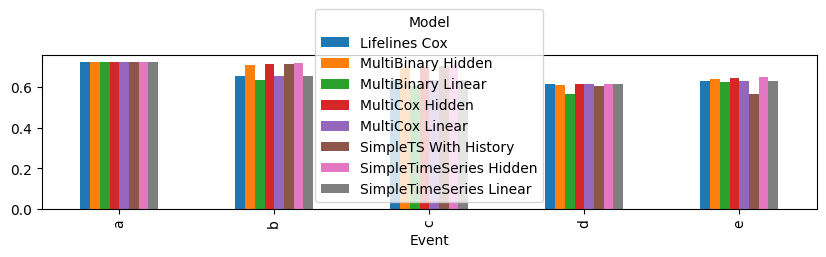

In [151]:
cindex_pivot.plot.bar(figsize = (10,2))

In [202]:
def compute_cindex_from_step(step_idx, population, df_test, models,
                              COVARIATE_COLS, EXTENDED_COLS, EVENT_TYPES,
                              x2_test, X_test, N_INTERVALS):
    """
    Compute C-index for all models predicting from step_idx onwards,
    on test patients still at risk at t_history = step_idx * step_forward.
    """
    t_history = step_idx * population.step_forward
    t_end     = population.history[-1]['end'].iloc[0]

    df_final_test = population.history[-1].set_index('id').loc[df_test['id'].values]
    df_state_test = population.history[step_idx].set_index('id').loc[df_test['id'].values]

    cindex_list = []

    for k, event in enumerate(EVENT_TYPES):

        # --- ground truth from final state, test patients only ---
        T_event   = df_final_test[f'first_{event}'].values
        eligible  = ~(pd.notna(T_event) & (T_event <= t_history))
        duration  = np.where(
            pd.notna(T_event) & (T_event > t_history),
            T_event - t_history,
            t_end   - t_history
        )
        event_obs = (pd.notna(T_event) & (T_event > t_history)).astype(int)
        n_ev      = event_obs[eligible].sum()
        n_elig    = eligible.sum()

        def add_cindex(model_name, risk_scores):
            c = concordance_index(duration[eligible], -risk_scores[eligible], event_obs[eligible])
            cindex_list.append({'Model': model_name, 'Event': event, 'C-Index': c})
            #print(f"  {model_name:40s} | Event {event}: {c:.4f}  "  f"(n_events={n_ev}, n_eligible={n_elig})")

        # 1. Lifelines Cox
        risk = models['lifelines_cox'][event].predict_partial_hazard(
            df_test[COVARIATE_COLS]).values
        add_cindex('Lifelines Cox', risk)

        # 2. MultiCox Linear
        with torch.no_grad():
            eta = models['multicox_no_hidden'](x2_test).numpy()
        add_cindex('MultiCox Linear', eta[:, k])

        # 3. MultiCox Hidden
        with torch.no_grad():
            eta = models['multicox_with_hidden'](x2_test).numpy()
        add_cindex('MultiCox Hidden', eta[:, k])

        # 4. MultiBinary Linear
        with torch.no_grad():
            eta = models['multibinary_no_hidden'].get_eta(
                torch.FloatTensor(X_test)).numpy()
        add_cindex('MultiBinary Linear', eta[:, k])

        # 5. MultiBinary Hidden
        with torch.no_grad():
            eta = models['multibinary_with_hidden'].get_eta(
                torch.FloatTensor(X_test)).numpy()
        add_cindex('MultiBinary Hidden', eta[:, k])

        # 6. SimpleTS Linear
        with torch.no_grad():
            eta = models['simple_time_series_linear'].get_eta(
                torch.FloatTensor(df_test[COVARIATE_COLS].values)).numpy()
        add_cindex('SimpleTS Linear', eta[:, k])

        # 7. SimpleTS Hidden
        with torch.no_grad():
            eta = models['simple_t_series'].get_eta(
                torch.FloatTensor(df_test[COVARIATE_COLS].values)).numpy()
        add_cindex('SimpleTS Hidden', eta[:, k])

        # 8. SimpleTS With History — prev_{e} from actual state at step_idx
        df_test_hist = df_test[['id'] + COVARIATE_COLS].copy()
        for e in EVENT_TYPES:
            df_test_hist[f'prev_{e}'] = (df_state_test[f'first_{e}'].notna() & 
                                          (df_state_test[f'first_{e}'] < t_history)).astype(float).values
        with torch.no_grad():
            eta = models['simple_t_series_with_history'].get_eta(
                torch.FloatTensor(df_test_hist[EXTENDED_COLS].values)).numpy()
        add_cindex('SimpleTS With History', eta[:, k])

    df_out = pd.DataFrame(cindex_list)
    pivot  = df_out.pivot_table(index='Event', columns='Model', values='C-Index').round(3)
    pivot["baseline_t"] = t_history
    return pivot

In [206]:
r0 = compute_cindex_from_step(0, population, df_test, models, COVARIATE_COLS, EXTENDED_COLS, EVENT_TYPES, x2_test, X_test, N_INTERVALS)
r1 = compute_cindex_from_step(1, population, df_test, models, COVARIATE_COLS, EXTENDED_COLS, EVENT_TYPES, x2_test, X_test, N_INTERVALS)
r2 = compute_cindex_from_step(2, population, df_test, models, COVARIATE_COLS, EXTENDED_COLS, EVENT_TYPES, x2_test, X_test, N_INTERVALS)
r4 = compute_cindex_from_step(4, population, df_test, models, COVARIATE_COLS, EXTENDED_COLS, EVENT_TYPES, x2_test, X_test, N_INTERVALS)

In [207]:
r0[["baseline_t", "MultiCox Linear", "MultiCox Hidden", "SimpleTS Hidden", "SimpleTS With History"]]

Model,baseline_t,MultiCox Linear,MultiCox Hidden,SimpleTS Hidden,SimpleTS With History
Event,,,,,
a,0,0.722,0.722,0.722,0.722
b,0,0.656,0.712,0.719,0.714
c,0,0.632,0.699,0.708,0.706
d,0,0.615,0.616,0.614,0.605
e,0,0.630,0.643,0.647,0.568


In [208]:
r1[["baseline_t", "MultiCox Linear", "MultiCox Hidden", "SimpleTS Hidden", "SimpleTS With History"]]

Model,baseline_t,MultiCox Linear,MultiCox Hidden,SimpleTS Hidden,SimpleTS With History
Event,,,,,
a,2,0.688,0.688,0.688,0.688
b,2,0.655,0.696,0.701,0.719
c,2,0.610,0.669,0.680,0.680
d,2,0.620,0.621,0.633,0.625
e,2,0.637,0.651,0.654,0.650


In [210]:
r4[["baseline_t", "MultiCox Linear", "MultiCox Hidden", "SimpleTS Hidden", "SimpleTS With History"]]

Model,baseline_t,MultiCox Linear,MultiCox Hidden,SimpleTS Hidden,SimpleTS With History
Event,,,,,
a,8,0.644,0.645,0.646,0.652
b,8,0.647,0.649,0.655,0.677
c,8,0.602,0.644,0.653,0.653
d,8,0.648,0.650,0.655,0.647
e,8,0.626,0.640,0.643,0.711
